# Data Project from " Gett "

## Assignment
Please complete the following tasks.

1. Build up distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection.     Analyse the resulting plot. Which category has the highest number of orders?
2. Plot the distribution of failed orders by hours. Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?
3. Plot the average time to cancellation with and without driver, by the hour. If there are any outliers in the data, it would be better to remove them. Can we draw any conclusions from this plot?
4. Plot the distribution of average ETA by hours. How can this plot be explained?
5. Hexagons. Using the h3 and folium packages, calculate how many sizes 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, colouring them by the number of fails on the map.


## Read and Explore the Datasets

In [1]:
# We use the Pandas library to load the CSVs into a DataFrame structure.
import pandas as pd

In [2]:
orders = pd.read_csv(filepath_or_buffer="data_orders.csv")

In [3]:
# # of rows, columns
orders.shape

(10716, 8)

In [4]:
# the random_state argument ensures that we get the same sample
# each time we call the method with the same arguments
orders.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
10309,00:29:14,-0.966062,51.454821,NaN,3000555146103,4,0,44.0
6705,01:28:45,-0.970472,51.456725,NaN,3000595870644,4,0,121.0
304,08:22:36,-0.916708,51.439852,NaN,3000627783633,9,0,NaN
9143,07:32:27,-0.955580,51.453493,1078.0,3000622140805,4,1,1017.0
10593,04:39:55,-0.946358,51.439779,NaN,3000554645524,4,0,121.0
8654,08:05:02,-0.967327,51.449395,598.0,3000592772077,4,1,48.0
3919,00:21:47,-0.971597,51.457574,NaN,3000624492441,4,0,180.0
4337,20:26:40,-0.971296,51.458115,NaN,3000628755869,4,0,104.0
6931,07:25:39,-0.942301,51.474812,NaN,3000628430595,4,0,44.0
967,13:41:31,-0.952194,51.444067,NaN,3000623591189,9,0,NaN


In [5]:
offers = pd.read_csv(filepath_or_buffer="data_offers.csv")

In [6]:
offers.shape

(334363, 2)

In [7]:
offers.sample(n=10, random_state=42)

,order_gk,offer_id
244971,3000627481054,300052086404
236783,3000631282042,300052342376
22714,3000624367715,300051909011
306983,3000557436646,300050769980
170256,3000588131807,300051201442
316173,3000629756224,300052250019
234398,3000625018320,300051967737
122107,3000629082264,300052196687
60909,3000588606991,300051225443
52998,3000629981908,300052274857


In [8]:
# Next, we would like to merge the two DataFrames into one, for easier manipulation. Pandas has the merge() method for doing exactly that.
# It is similar to joining tables in SQL. We specify how we want the merge to be carried out (inner) and on which column should it occur (order_gk).
# Then, we print a sample of the merged DataFrame.

df = orders.merge(right=offers, how="inner", on="order_gk")

In [9]:
df.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,4,1,223.0,300050725946
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,4,0,91.0,300052014519
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,4,0,68.0,300051458740
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,4,0,125.0,300052031394
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,4,0,11.0,300050671163
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,9,0,NaN,300051413313
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,4,0,6.0,300051090742
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,9,0,NaN,300051125957
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,4,0,113.0,300052078801
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,4,1,47.0,300051178628


In [10]:
# Should improve quality, Values in order_status_key and is_driver_assigned_key are not informative, Replace 1-0s with Yes-No, Same for 
# order_status_key

import numpy as np

df["is_driver_assigned"] = np.where(df["is_driver_assigned_key"] == 1, "Yes", "No")
df["order_status"] = np.where(df["order_status_key"] == 4, "Client Cancelled", "System Reject")

df.drop(columns=["is_driver_assigned_key", "order_status_key"], inplace=True)

In [11]:
df = df.rename(columns={
    "order_datetime": "order_time"
})

In [12]:
df.sample(n=10, random_state=42)

,order_time,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,NaN,300051413313,No,System Reject
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,6.0,300051090742,No,Client Cancelled
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,NaN,300051125957,No,System Reject
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,113.0,300052078801,No,Client Cancelled
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,47.0,300051178628,Yes,Client Cancelled


#### Question 1
###### Build up a distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. Analyse the resulting plot. Which category has the highest number of orders?

In [13]:
#  Use groupby is_driver_assigned and order_status columns
#  Highest number of cancellations is 13435 which is cancelled by client Before driver assignment, 9469 rejected by system, 8360 cancelled 
#  by client after driver assignment, 4 of them is rejected by the system itself

df.groupby(by=["is_driver_assigned", "order_status"])["order_gk"].count()

is_driver_assigned  order_status    
No                  Client Cancelled    13435
                    System Reject        9469
Yes                 Client Cancelled     8360
                    System Reject           4
Name: order_gk, dtype: int64

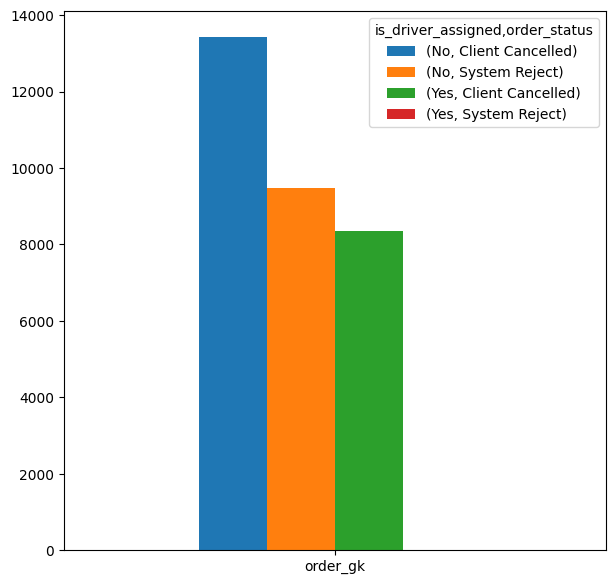

In [14]:
df_q1 = df.pivot_table(columns=["is_driver_assigned", "order_status"], values="order_gk", aggfunc="count")
_ = df_q1.plot(kind="bar", subplots=False, figsize=(7, 7), legend=True, rot=0)

In [15]:
df_q1

is_driver_assigned               No                            Yes  \
order_status       Client Cancelled System Reject Client Cancelled   
order_gk                      13435          9469             8360   

is_driver_assigned                
order_status       System Reject  
order_gk                       4

#### Question 2
###### Plot the distribution of failed orders by hours. Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?


In [16]:
# Here we dive deeper analysing failed orders & reveal when fails occur
# extract hour from the time column
# print a small sample to make sure that the transformation is correct

df["order_hour"] = df["order_time"].str.split(":").apply(lambda split: split[0])
df.sample(n=5, random_state=42)


,order_time,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status,order_hour
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,223.0,300050725946,Yes,Client Cancelled,21
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,91.0,300052014519,No,Client Cancelled,10
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,68.0,300051458740,No,Client Cancelled,09
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,125.0,300052031394,No,Client Cancelled,02
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,11.0,300050671163,No,Client Cancelled,21


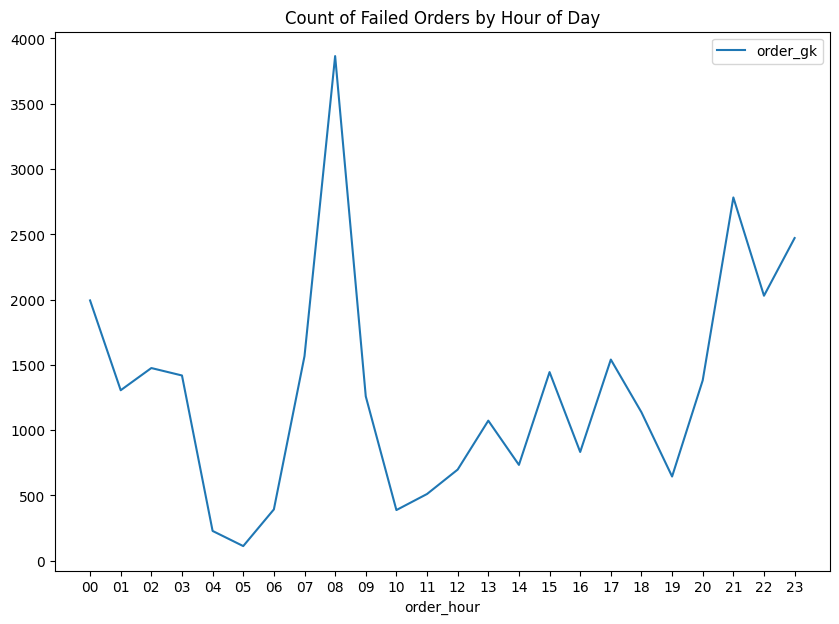

In [17]:
# This code groups the DataFrame 'df' by the 'order_hour' column, counts the number of failed orders ('order_gk') for each hour,
# then plots the result as a bar chart. The x-axis shows the hours of the day (0-23), and the y-axis shows the count of failed orders.
# The plot helps visualize at which hours the most failures occur, making it easier to identify trends or peak failure times.

X1 = df.groupby(by="order_hour")["order_gk"].count().plot(figsize=(10, 7),
                                                         legend=True,
                                                         xticks=range(0, 24),
                                                         title="Count of Failed Orders by Hour of Day")

In [18]:
# Group them by order hour, driver assignment status, and order status and count

grouped_q2 = df.groupby(by=["order_hour", "is_driver_assigned", "order_status"])["order_gk"].count()
grouped_q2

order_hour  is_driver_assigned  order_status    
00          No                  Client Cancelled     957
                                System Reject        706
            Yes                 Client Cancelled     326
                                System Reject          4
01          No                  Client Cancelled     633
                                                    ... 
22          No                  System Reject        660
            Yes                 Client Cancelled     415
23          No                  Client Cancelled    1144
                                System Reject        883
            Yes                 Client Cancelled     444
Name: order_gk, Length: 73, dtype: int64

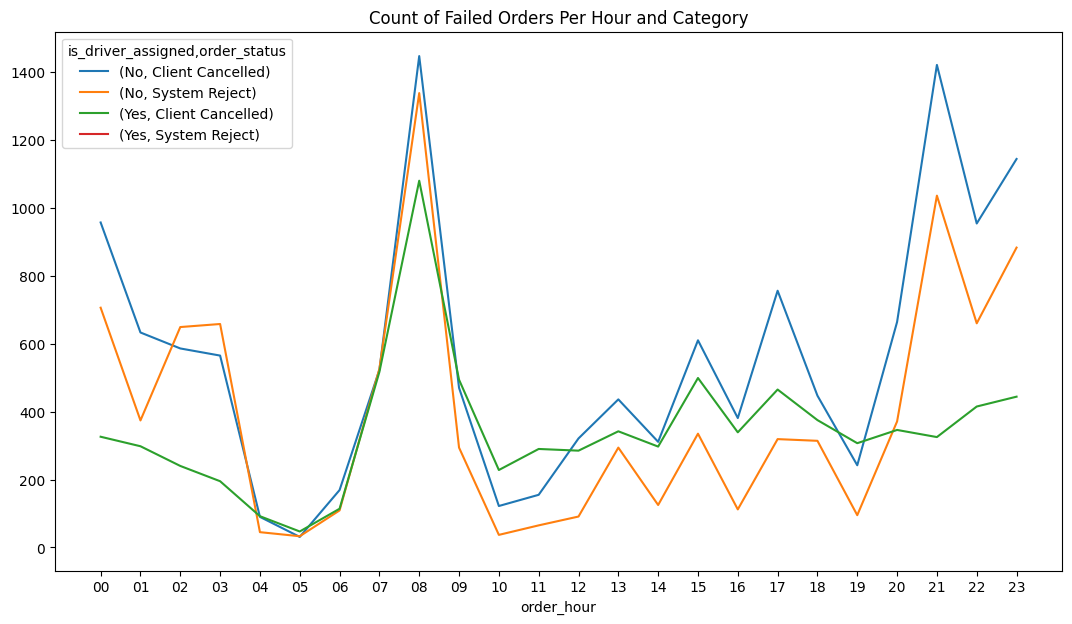

In [19]:
X2 = grouped_q2.reset_index().pivot(index="order_hour",
                                   columns=["is_driver_assigned", "order_status"],
                                   values="order_gk").plot(xticks=range(0, 24),
                                                           figsize=(13, 7),
                                                           title="Count of Failed Orders Per Hour and Category")

##### The four system rejects with the assigned driver occurred around midnight. Other categories  follow similar distribution, with the client 
##### cancellations with the assigned driver having a substantially lower count during the night hours.

#### Question 3
###### Plot the average time to cancellation with and without driver, by hour. Can we draw any conclusions from this plot?

In [20]:
# Aggregate DF by order hour & driver assignment, aggregate time column mean().count

grouped_q3 = df.groupby(by=["order_hour", "is_driver_assigned"])["cancellations_time_in_seconds"].mean()
grouped_q3

order_hour  is_driver_assigned
00          No                    115.126437
            Yes                   276.082822
01          No                    100.593997
            Yes                   296.312081
02          No                    121.305461
            Yes                   301.466667
03          No                    129.182301
            Yes                   368.682051
04          No                    100.733333
            Yes                   245.250000
05          No                    102.838710
            Yes                   156.617021
06          No                    202.952663
            Yes                   225.508772
07          No                    141.177820
            Yes                   177.640232
08          No                    132.625432
            Yes                   172.896296
09          No                    138.014894
            Yes                   230.821862
10          No                     93.795082
            Yes         

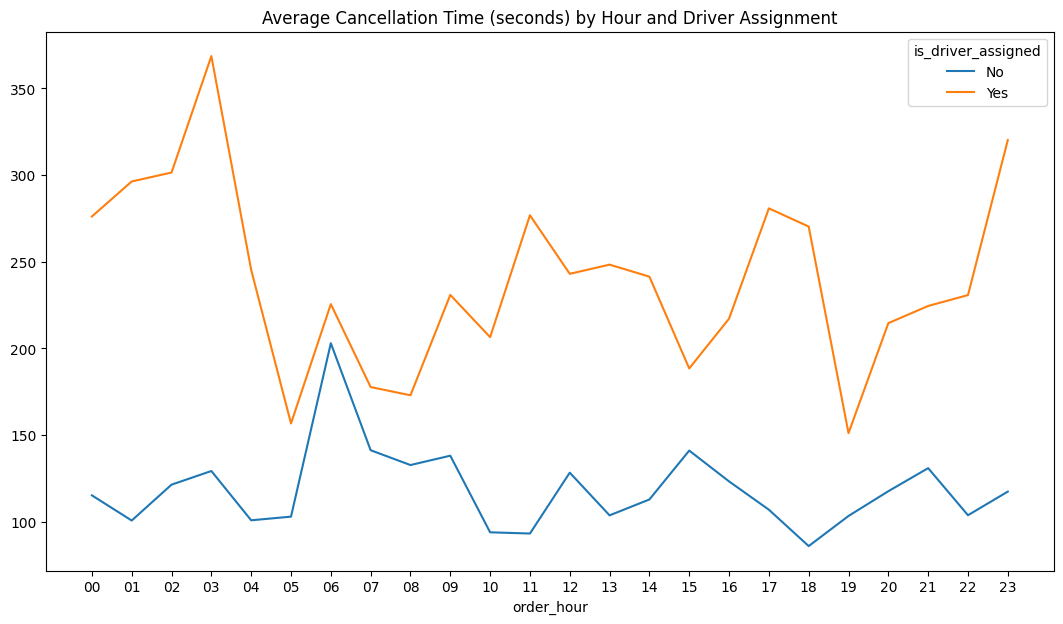

In [21]:
# First Reshape the data with .pivot() then visualize that reshaped data with .plot()

X3 = grouped_q3.reset_index().pivot(index="order_hour", 
                                   columns=["is_driver_assigned"],
                                   values="cancellations_time_in_seconds").plot(xticks=range(0, 24),
                                                                             figsize=(13, 7),
                                                                             title="Average Cancellation Time (seconds) by Hour and Driver Assignment")

#### Average cancellation time is higher with a driver assigned, each hour shows same pattern, peak is reached at 3 AM, This might be driver delays or late assignment of a driver or inactivity over the app.

#### Question 4
###### Plot the distribution of average ETA by hours. How can this plot be explained?

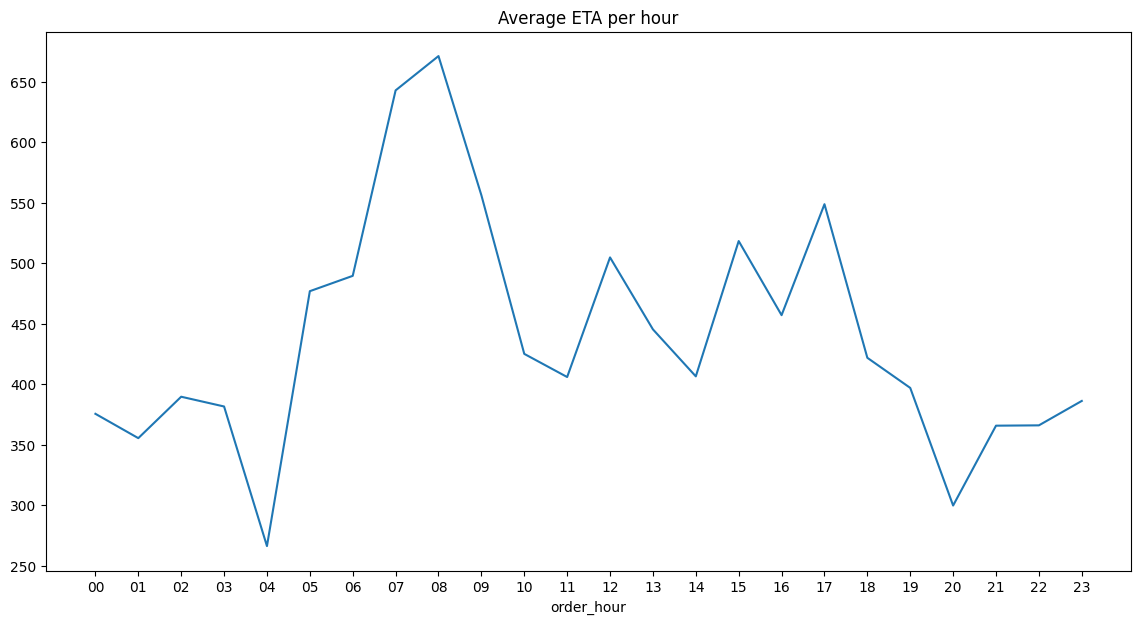

In [22]:
# group df by order_hour, get mean of eta, plot it

X4 = df.groupby(by="order_hour")["m_order_eta"].mean().plot(figsize=(14, 7),
                                                            xticks=range(0, 24),
                                                            title="Average ETA per hour")

#### Matches the pattern orders per hour graph, number of failed orders increases when wait time is higher.

#### Question 5
###### Using the h3 and folium packages, calculate how many size 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, 
###### colouring them by the number of fails on the map.

In [23]:
# pip install h3

import h3
import folium

In [24]:
df["hex_id"] = df.apply(
    func=lambda row: h3.latlng_to_cell(lat=row["origin_latitude"], lng=row["origin_longitude"], res=8), axis=1)

In [25]:
grouped_q5 = df.groupby(by="hex_id")["order_gk"].count()
grouped_q5.shape

(139,)

In [26]:
grouped_q5 = grouped_q5.reset_index()
grouped_q5.sample(n=5, random_state=42)

,hex_id,order_gk
135,88195d74d1fffff,1
66,88195d2a33fffff,12
31,88195d2941fffff,52
118,88195d2b5dfffff,31
42,88195d2961fffff,5


In [27]:
# To find how many hexagons contain 80% of all orders, we'll do a cumulative analysis:
# Sort hexagons by order count (highest first)
# Calculate total orders across all hexagons
# Create running totals using cumulative sum
# Convert to percentages of total orders
# Find the 80% cutoff point

grouped_q5 = grouped_q5.sort_values(by="order_gk", ascending=False)
total_orders = grouped_q5["order_gk"].sum()
grouped_q5["cum_sum"] = grouped_q5["order_gk"].cumsum()
grouped_q5["cum_perc"] = 100 * grouped_q5["cum_sum"] / total_orders
grouped_q5[grouped_q5["cum_perc"] <= 80]

,hex_id,order_gk,cum_sum,cum_perc
93,88195d2b1dfffff,4488,4488,14.353332
92,88195d2b1bfffff,2603,7091,22.678137
89,88195d2b15fffff,2461,9552,30.548804
87,88195d2b11fffff,2191,11743,37.555968
91,88195d2b19fffff,1960,13703,43.824357
20,88195d284dfffff,1937,15640,50.019189
61,88195d2a27fffff,1295,16935,54.160803
85,88195d2b0bfffff,1091,18026,57.649994
60,88195d2a25fffff,1074,19100,61.084815
88,88195d2b13fffff,975,20075,64.203019


In [28]:
total_hex = len(grouped_q5[grouped_q5["cum_perc"] <= 80])
print(f"Busiest hexagons needed for 80% order coverage: {total_hex}")

Busiest hexagons needed for 80% order coverage: 20


In [29]:
map = folium.Map(location=[df["origin_latitude"].mean(), df["origin_longitude"].mean()],
                 zoom_start=8.5,  # after a bit of experimentation, we thought this presents the map best
                 tiles="cartodbpositron")

In [30]:
pip install GeoJSON

Note: you may need to restart the kernel to use updated packages.


In [31]:
import json
import geojson
import h3.api.basic_int as h3  # using the integer-based API

def to_geojson(row):
    """Transform hex_id into a GeoJSON feature."""
    # Convert hex string to integer (required by basic_int API)
    int_cell = int(row["hex_id"], 16)

    # Get boundary in [lat, lng], flip to [lng, lat] for GeoJSON
    latlngs = h3.cell_to_boundary(int_cell)
    lnglats = [[lng, lat] for lat, lng in latlngs]

    geometry = {
        "type": "Polygon",
        "coordinates": [lnglats]
    }

    return geojson.Feature(
        id=row["hex_id"],
        geometry=geometry,
        properties={"order_gk": row["order_gk"]}
    )

# Apply function row-wise and collect GeoJSON features
geojsons = grouped_q5.apply(to_geojson, axis=1).tolist()
geojson_str = json.dumps(geojson.FeatureCollection(geojsons))

In [32]:
import matplotlib

colormap = matplotlib.colormaps["plasma"]  # 
max_order_gk = grouped_q5["order_gk"].max()
min_order_gk = grouped_q5["order_gk"].min()

X5 = folium.GeoJson(data=geojson_str, style_function=lambda f: {
    "fillColor": matplotlib.colors.to_hex(
        colormap((f["properties"]["order_gk"] - min_order_gk) / (max_order_gk - min_order_gk))),
    "color": "black",
    "weight": 1,
    "fillOpacity": 0.7
}).add_to(map)

In [33]:
map.save("map.html")


In [36]:
from IPython.display import HTML
HTML(map._repr_html_())